In [4]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [5]:
def generate_true_duration_histogram(annotation_json_path, output_filename):
    # 1. Load the ground truth annotations
    with open(annotation_json_path, 'r', encoding='utf-8') as f:
        dataset = json.load(f)

    anomaly_durations = []

    # 2. Extract the duration of every single anomalous event
    # The new format is a list of dictionaries representing each video
    for item in dataset:
        # Skip normal videos (they have no anomalies)
        if item.get("label") == "Normal":
            continue
            
        # Extract timestamps from the injected UCA data
        uca_data = item.get("uca_data", {})
        timestamps = uca_data.get("timestamps", [])
        
        for window in timestamps:
            # The new JSON already has clean float timestamps in seconds
            if len(window) == 2:
                start_time = window[0]
                end_time = window[1]
                
                # Calculate duration in seconds
                duration = end_time - start_time
                
                # Filter out any zero-length or negative annotations
                if duration > 0:
                    anomaly_durations.append(duration)

    print(f"Extracted {len(anomaly_durations)} valid anomaly events from the dataset.")

    if not anomaly_durations:
        print("No valid anomalies found. Check your JSON path or structure.")
        return

    # 3. Force a crisp academic light theme
    sns.set_theme(style="whitegrid", rc={"axes.facecolor": "white", "figure.facecolor": "white"})
    plt.figure(figsize=(10, 6))

    # Create the histogram, filtering the extreme outliers just for the visualization
    # Zooming in on anomalies between 0 and 200 seconds
    ax = sns.histplot(
        anomaly_durations, 
        bins=100,             # Granular bins
        binrange=(0, 200),    # Force bins to only calculate within this range
        kde=True, 
        color="#2c7bb6", 
        edgecolor="black",
        linewidth=0.8,
        alpha=0.7
    )

    # 4. Calculate and plot statistics (Calculated on ALL valid data)
    mean_val = np.mean(anomaly_durations)
    median_val = np.median(anomaly_durations)

    plt.axvline(mean_val, color='#d7191c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}s')
    plt.axvline(median_val, color='#fdae61', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}s')

    # Force the X-axis to cut off the extreme outliers for better readability
    plt.xlim(0, 200)

    # 5. Formatting labels and title (using dark text for light background)
    plt.title('Distribution of Anomaly Durations in the UCF-Crime Train Split', fontsize=15, weight='bold', pad=15, color='black')
    plt.xlabel('Anomaly Duration (Seconds)', fontsize=13, weight='bold', color='black')
    plt.ylabel('Frequency', fontsize=13, weight='bold', color='black')
    
    plt.xticks(fontsize=11, color='black')
    plt.yticks(fontsize=11, color='black')
    
    # Add gridlines for readability
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black')

    # 6. Save as a perfect vector graphic for LaTeX
    # Ensure the target directory exists
    output_path = Path(output_filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.tight_layout()
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Histogram successfully saved to {output_path.resolve()}")
    plt.show()

Extracted 6078 valid anomaly events from the dataset.
Histogram successfully saved to /hdd/Documents/Projects/miniLAVAD/figures/anomaly_duration_histogram.pdf


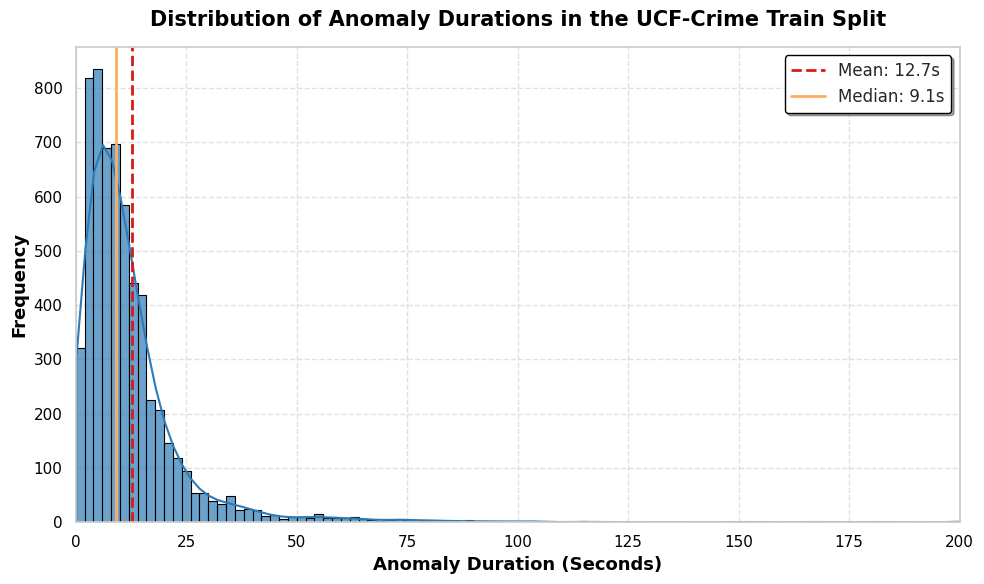

In [8]:
# Dynamically resolve paths based on project root
PROJECT_ROOT = Path.cwd().parent

TRAIN_SPLIT_PATH = PROJECT_ROOT / "data" / "processed" / "train_split.json"
OUTPUT_PDF = PROJECT_ROOT / "figures" / "anomaly_duration_histogram.pdf"

generate_true_duration_histogram(TRAIN_SPLIT_PATH, OUTPUT_PDF)